# Telco Customer Churn — EDA

In this notebook, we explore the dataset, check data quality, and prepare it for machine learning.

We will:
- Load data
- Check structure
- Find missing values
- Detect data problems
  

In [2]:
import pandas as pd

df = pd.read_csv("../data/train.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No
5,8414-OOEEL,Male,0,No,Yes,66,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),79.50,5196.1,No
6,8562-GHPPI,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.80,19.8,No
7,8017-UVSZU,Female,0,Yes,No,40,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),56.60,2379.1,No
8,1972-XMUWV,Female,0,Yes,No,65,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,Yes,Credit card (automatic),59.80,3808.2,No
9,2054-PJOCK,Female,0,No,No,60,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),80.55,4847.05,No


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Quality Check

We inspect the dataset for missing values and structural issues.

Key observation:
- There are NO explicit missing values (no NaN entries in any column).
- However, some features may contain *hidden issues* (e.g. incorrect data types or malformed values).

One important problem is the `TotalCharges` column, which is stored as text instead of numeric values.
This must be fixed before any modeling or analysis.

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(8)

The missing values in TotalCharges were not originally marked as NaN.
They were implicitly missing due to malformed string entries (e.g., empty spaces), which were revealed only after type conversion.

In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

We replace missing values using the median of the column.
This is a safe initial strategy since the number of missing values is very small and does not significantly affect distribution.

This ensures the feature is fully numeric and ready for analysis and modeling.

# Target Analysis (Churn Distribution)

We first analyze the distribution of the target variable (Churn).
This helps us understand class imbalance, which is critical for model training and evaluation.

In [10]:
df["Churn"].value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

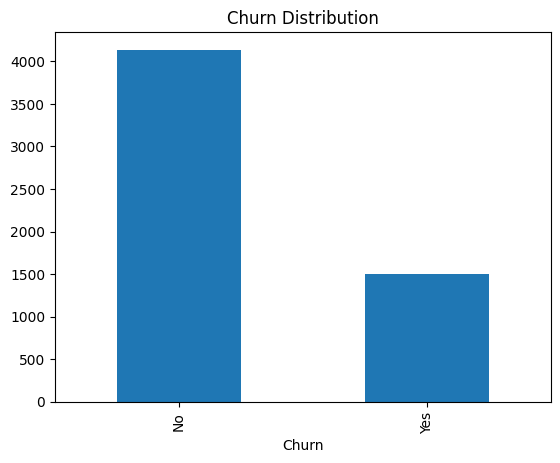

In [11]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

# Contract Type vs Churn

We analyze how contract type affects customer churn behavior.

This feature is expected to be highly predictive based on business intuition, as short-term contracts usually have higher churn rates.

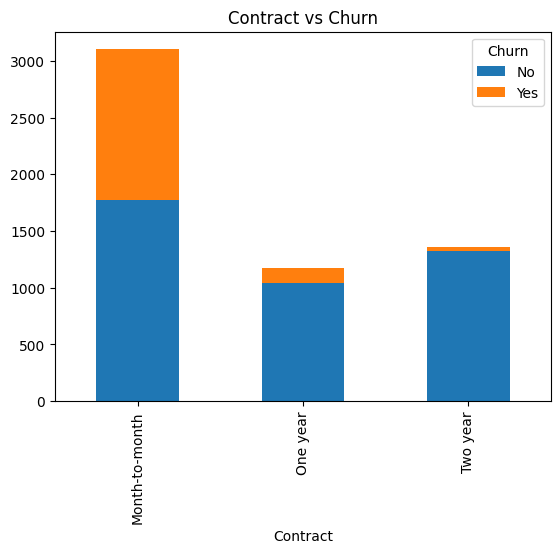

In [12]:
import pandas as pd

pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar", stacked=True)
plt.title("Contract vs Churn")
plt.show()

# Churn Rate by Contract Type

We compute churn rates within each contract category to quantify the relationship between contract duration and customer attrition.

This helps identify the most high-risk customer segments.

In [13]:
df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()

Churn,No,Yes
Contract,,
Month-to-month,0.572534,0.427466
One year,0.889173,0.110827
Two year,0.971302,0.028698


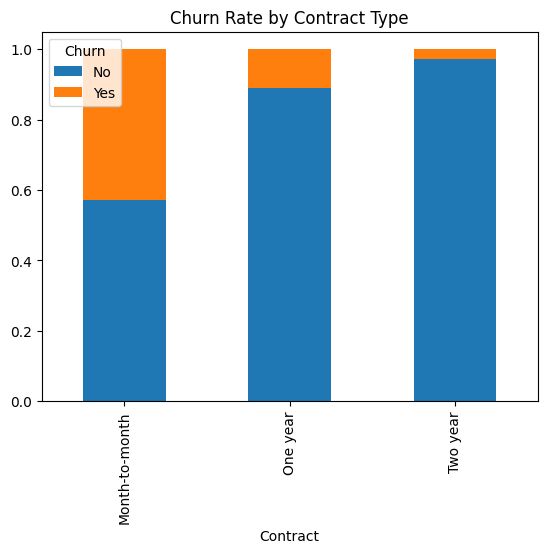

In [14]:
import matplotlib.pyplot as plt

pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.show()

Customers with month-to-month contracts have the highest churn rate, while longer contracts are associated with much lower churn.

# Tenure vs Churn Analysis

We analyze how customer tenure (months of subscription) affects churn behavior.

This helps us understand whether long-term customers are more loyal or not.

In [18]:
import matplotlib.pyplot as plt

df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,4139.0,37.587582,24.143446,0.0,15.0,38.0,61.0,72.0
Yes,1495.0,18.358528,19.737939,1.0,2.0,10.0,29.0,72.0


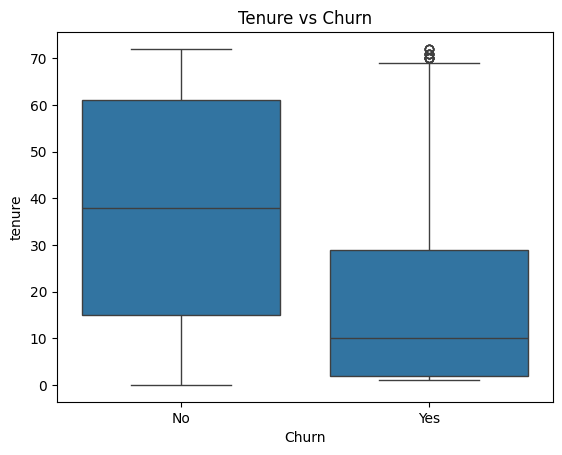

In [19]:
import seaborn as sns

sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

Customers with low tenure are more likely to churn, suggesting that the highest churn risk occurs during the early stages of the customer lifecycle.

# Monthly Charges vs Churn

We analyze the relationship between monthly charges and customer churn.

This helps us understand whether higher monthly costs are associated with increased customer attrition.

In [20]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,4139.0,61.343187,31.135396,18.40,25.15,64.40,88.175,118.75
Yes,1495.0,74.860167,24.603757,18.85,56.90,79.95,94.400,118.35


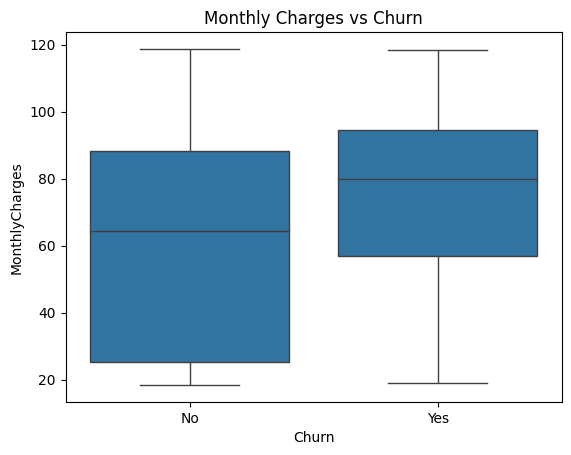

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers who churn tend to have higher monthly charges than those who stay, suggesting a positive association between monthly cost and churn risk.

# Total Charges vs Churn

We analyze the relationship between total charges and customer churn.

This helps us understand whether long-term customer value is associated with retention behavior.

In [22]:
df.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,4139.0,2567.426359,2341.038939,18.90,578.75,1686.15,4266.775,8672.45
Yes,1495.0,1564.587893,1908.838251,18.85,144.35,740.30,2368.725,8684.80


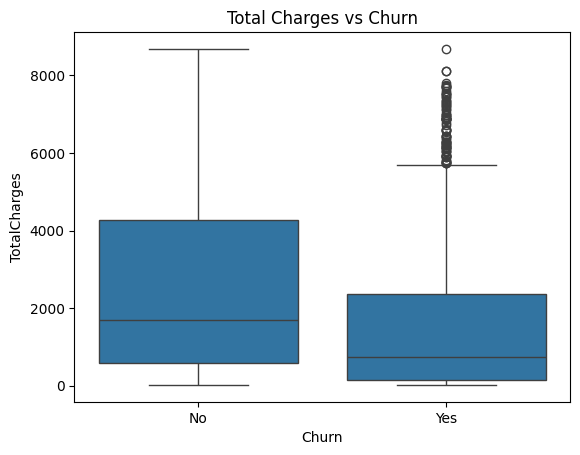

In [23]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges vs Churn")
plt.show()

Customers who stay have significantly higher TotalCharges than customers who churn.

This is likely related to customer tenure, as long-term customers accumulate higher total payments and are generally less likely to leave.

# Internet Service vs Churn

We analyze how different types of internet service relate to customer churn behavior.

This helps us understand whether service type influences customer retention.

In [24]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.813113,0.186887
Fiber optic,0.579138,0.420862
No,0.927512,0.072488


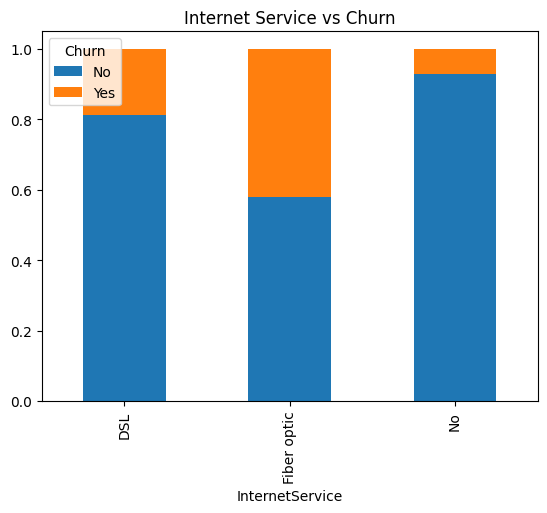

In [25]:
import matplotlib.pyplot as plt

pd.crosstab(df["InternetService"], df["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Internet Service vs Churn")
plt.show()

Customers using Fiber optic internet show significantly higher churn rates compared to DSL and non-internet users. This suggests a strong association between internet service type and customer retention, likely influenced by pricing and service expectations.

# Payment Method vs Churn

We analyze how different payment methods relate to customer churn behavior.

This helps us understand whether payment friction or automation affects customer retention.

In [26]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.838424,0.161576
Credit card (automatic),0.850783,0.149217
Electronic check,0.542570,0.457430
Mailed check,0.807154,0.192846


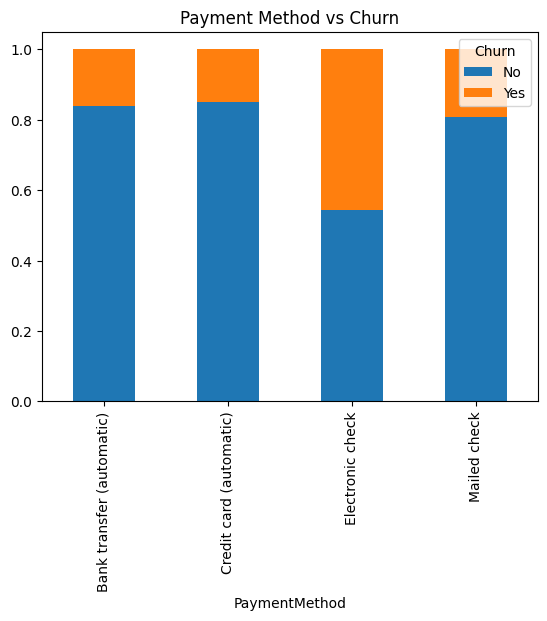

In [27]:
import matplotlib.pyplot as plt

pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Payment Method vs Churn")
plt.show()

Customers using Electronic Check show significantly higher churn rates compared to other payment methods. This suggests that lower payment automation and higher transactional friction are associated with increased churn risk.

# Feature Correlation Analysis

We analyze correlations between numerical features to detect redundancy and hidden relationships between variables.

This helps improve feature selection and engineering decisions.

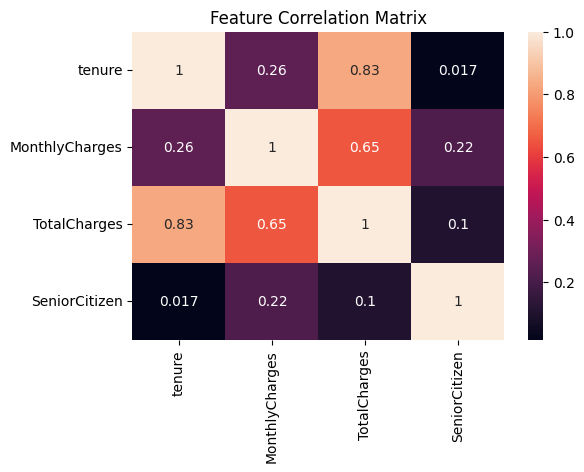

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

corr = df[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

We observe a strong correlation between TotalCharges and tenure, indicating redundancy in these features. MonthlyCharges is moderately correlated with TotalCharges, while SeniorCitizen shows weak linear relationships with other variables.

This suggests that TotalCharges is derived information and should be carefully handled during feature engineering.